# Data-registered 4D tracking of segmented DFXM cell volumes

This notebook is the version you asked for: **registration is not based on the mask**.

The registration is based on the segmented cell data itself:

1. Each labelled cell is represented by its **median orientation vector**.
2. This creates a cell-wise orientation field, where every voxel of a cell has the same median \((\chi, \phi)\)-like vector.
3. A boundary/contact map is also computed from the labels.
4. A data-based scalar registration feature is built from:
   - cell-median orientation structure;
   - cell boundary structure.
5. Volumes are registered to a common reference by translation.
6. Cell tracking is then performed using a feature-vector score:
   - overlap;
   - centroid distance;
   - volume similarity;
   - median orientation difference;
   - optional split/merge/birth/death classification.

This is meant to support thesis-level language such as: *cells were tracked by combining spatial overlap, morphology, and median orientation in the registered 3D volumes*.

Expected input folder:

```text
~/Documents/Data/4dcells/111_june/disell_batch_output/
```

Expected files per strain step:

```text
registered_volume.npy
seg_input.npy
mask.npy
labels.npy
rgb_volume.npy
summary.json
cell_table.csv
neighbour_table.csv
```


## 1. Imports and configuration

In [48]:
from pathlib import Path
import json
import re
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import ndimage as ndi
from scipy import stats
from scipy.spatial import cKDTree
from skimage.registration import phase_cross_correlation
from skimage.segmentation import find_boundaries, relabel_sequential

# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------

output_root = Path("~/Documents/Data/4dcells/111_june/disell_batch_output").expanduser()

dataset_order = [
    "111_cells_2_6-1pct_mosalayers_2x_redo",
    "111_cells_2_6-2pct_mosalayers_2x",
    "111_cells_2_6-3pct_mosalayers_2x",
    "111_cells_2_6-4pct_mosalayers_2x",

]

# Replace with calibrated true strains if needed.
strain_percent = {
    "111_cells_2_6-1pct_mosalayers_2x_redo": 6.1,
    "111_cells_2_6-2pct_mosalayers_2x": 6.2,
    "111_cells_2_6-3pct_mosalayers_2x": 6.3,
    "111_cells_2_6-4pct_mosalayers_2x": 6.4,

}

# ---------------------------------------------------------------------
# Registration parameters
# ---------------------------------------------------------------------

# Middle strain step is a stable default reference.
ref_index = len(dataset_order) // 2

# Phase-correlation gives the initial translation.
# 1 = integer voxel. 2 or 4 = sub-voxel. For labels we eventually round/apply nearest.
upsample_factor = 1

# After phase correlation, refine the shift by a small brute-force local search
# using the full orientation/boundary feature score.
local_refine_radius = (1, 4, 8)  # search +/- in z, y, x around initial shift
local_refine_step = 1

# Data-registration feature weights.
registration_weight_orientation = 1.0
registration_weight_boundary = 0.35

# ---------------------------------------------------------------------
# Tracking parameters
# ---------------------------------------------------------------------

min_overlap_voxels = 5

# Candidate pairs are generated both from spatial overlap and centroid proximity.
max_centroid_distance = 25.0  # voxels; tune after looking at assignment distances

# Score scales. These are not physical constants. They map distances to similarities.
centroid_scale = 10.0
orientation_scale = 0.25

# Final assignment/event thresholds.
min_score_for_assignment = 1.0
min_score_for_events = 1.0
min_frac_parent_for_events = 0.05

print("output_root:", output_root)
print("exists:", output_root.exists())

output_root: /home/adam/Documents/Data/4dcells/111_june/disell_batch_output
exists: True


## 2. Load segmented volumes

In [49]:
datasets = []

for name in dataset_order:
    d = output_root / name
    if not d.exists():
        print("[skip missing]", d)
        continue

    required = [
        "registered_volume.npy",
        "seg_input.npy",
        "mask.npy",
        "labels.npy",
        "rgb_volume.npy",
        "summary.json",
    ]
    missing = [f for f in required if not (d / f).exists()]
    if missing:
        print("[skip incomplete]", name, "missing:", missing)
        continue

    with open(d / "summary.json") as f:
        summary = json.load(f)

    item = {
        "name": name,
        "strain_percent": strain_percent.get(name, summary.get("nominal_strain_percent")),
        "path": d,
        "registered": np.load(d / "registered_volume.npy"),
        "seg_input": np.load(d / "seg_input.npy"),
        "mask": np.load(d / "mask.npy").astype(bool),
        "labels": np.load(d / "labels.npy").astype(np.int32),
        "rgb": np.load(d / "rgb_volume.npy"),
        "summary": summary,
    }

    if (d / "cell_table.csv").exists():
        item["cell_table"] = pd.read_csv(d / "cell_table.csv")
    if (d / "neighbour_table.csv").exists():
        item["neighbour_table"] = pd.read_csv(d / "neighbour_table.csv")

    datasets.append(item)

print("loaded:", len(datasets))
for i, item in enumerate(datasets):
    print(
        i,
        item["name"],
        "strain:", item["strain_percent"],
        "registered:", item["registered"].shape,
        "labels:", item["labels"].shape,
        "max label:", int(item["labels"].max()),
        "coverage:",
        item["summary"].get("final_coverage_inside_mask"),
    )

loaded: 4
0 111_cells_2_6-1pct_mosalayers_2x_redo strain: 6.1 registered: (11, 200, 500, 2) labels: (11, 200, 500) max label: 2851 coverage: 1.0
1 111_cells_2_6-2pct_mosalayers_2x strain: 6.2 registered: (11, 200, 500, 2) labels: (11, 200, 500) max label: 2809 coverage: 1.0
2 111_cells_2_6-3pct_mosalayers_2x strain: 6.3 registered: (11, 200, 500, 2) labels: (11, 200, 500) max label: 2841 coverage: 1.0
3 111_cells_2_6-4pct_mosalayers_2x strain: 6.4 registered: (11, 200, 500, 2) labels: (11, 200, 500) max label: 2869 coverage: 1.0


## 3. Expand all volumes to a common z-layer grid

One dataset has 12 layers while others have 11. This notebook does not blindly crop or pad. It reads `summary.json["layer_names"]`, parses the acquisition layer IDs, and places each volume into a shared z grid.

Missing layers are filled with neutral values:

```text
registered_volume: NaN
seg_input:         0
mask:              False
labels:            0
rgb:               0
```


In [50]:
def parse_layer_number(layer_name):
    m = re.search(r"layer[_-]?(\d+)", layer_name)
    if m is None:
        raise ValueError(f"Could not parse layer number from {layer_name!r}")
    return int(m.group(1))


for item in datasets:
    layer_names = item["summary"].get("layer_names")
    if layer_names is None:
        raise KeyError(f"{item['name']} has no layer_names in summary.json")

    layer_ids = [parse_layer_number(x) for x in layer_names]
    print(item["name"], "n_layers:", len(layer_ids), "layer ids:", layer_ids)


all_layer_ids = sorted(
    {
        parse_layer_number(layer_name)
        for item in datasets
        for layer_name in item["summary"]["layer_names"]
    }
)
layer_to_common_index = {layer_id: i for i, layer_id in enumerate(all_layer_ids)}

print("\ncommon layer IDs:", all_layer_ids)
print("common z size:", len(all_layer_ids))


def expand_z_to_common_layers(arr, layer_names, fill_value):
    layer_ids = [parse_layer_number(name) for name in layer_names]

    if arr.shape[0] != len(layer_ids):
        raise ValueError(
            f"z mismatch: arr has {arr.shape[0]} layers, "
            f"but layer_names has {len(layer_ids)} entries"
        )

    out_shape = (len(all_layer_ids),) + arr.shape[1:]
    out = np.full(out_shape, fill_value, dtype=arr.dtype)

    for local_z, layer_id in enumerate(layer_ids):
        common_z = layer_to_common_index[layer_id]
        out[common_z] = arr[local_z]

    return out


for item in datasets:
    layer_names = item["summary"]["layer_names"]

    item["registered_commonz"] = expand_z_to_common_layers(
        item["registered"], layer_names, fill_value=np.nan
    )
    item["seg_input_commonz"] = expand_z_to_common_layers(
        item["seg_input"], layer_names, fill_value=0.0
    )
    item["mask_commonz"] = expand_z_to_common_layers(
        item["mask"].astype(bool), layer_names, fill_value=False
    ).astype(bool)
    item["labels_commonz"] = expand_z_to_common_layers(
        item["labels"].astype(np.int32), layer_names, fill_value=0
    ).astype(np.int32)
    item["rgb_commonz"] = expand_z_to_common_layers(
        item["rgb"], layer_names, fill_value=0.0
    )

print("\nExpanded shapes:")
for item in datasets:
    print(
        item["name"],
        "registered:", item["registered_commonz"].shape,
        "labels:", item["labels_commonz"].shape,
        "mask voxels:", np.count_nonzero(item["mask_commonz"]),
    )

111_cells_2_6-1pct_mosalayers_2x_redo n_layers: 11 layer ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
111_cells_2_6-2pct_mosalayers_2x n_layers: 11 layer ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
111_cells_2_6-3pct_mosalayers_2x n_layers: 11 layer ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
111_cells_2_6-4pct_mosalayers_2x n_layers: 11 layer ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

common layer IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
common z size: 11

Expanded shapes:
111_cells_2_6-1pct_mosalayers_2x_redo registered: (11, 200, 500, 2) labels: (11, 200, 500) mask voxels: 1091000
111_cells_2_6-2pct_mosalayers_2x registered: (11, 200, 500, 2) labels: (11, 200, 500) mask voxels: 1089304
111_cells_2_6-3pct_mosalayers_2x registered: (11, 200, 500, 2) labels: (11, 200, 500) mask voxels: 1091500
111_cells_2_6-4pct_mosalayers_2x registered: (11, 200, 500, 2) labels: (11, 200, 500) mask voxels: 1089804


## 4. Build data-based registration features from labelled cells

This is the important change.

The registration feature is **not the mask**. For each strain step:

1. Compute the median orientation vector for each labelled cell.
2. Paint the cell median back into every voxel of that cell.
3. Build a scalar orientation-structure feature from the cell-median orientation field.
4. Build a boundary/contact feature from the label map.
5. Combine these into a scalar volume for phase-correlation registration.

This way, registration is driven by **cell shapes and average cell orientations**, not by the FOV support.


In [51]:
def robust_zscore(arr, valid=None, clip=5.0):
    arr = np.asarray(arr, dtype=np.float32)
    out = arr.copy()

    finite = np.isfinite(out)
    if valid is not None:
        finite &= valid

    if not np.any(finite):
        return np.zeros_like(out, dtype=np.float32)

    med = np.nanmedian(out[finite])
    mad = np.nanmedian(np.abs(out[finite] - med))
    scale = 1.4826 * mad

    if not np.isfinite(scale) or scale < 1e-8:
        scale = np.nanstd(out[finite]) + 1e-8

    out[~np.isfinite(out)] = med
    out = (out - med) / (scale + 1e-8)

    if clip is not None:
        out = np.clip(out, -clip, clip)

    if valid is not None:
        out[~valid] = 0.0

    return out.astype(np.float32)


def compute_label_median_orientation_field(labels, orientation, mask):
    """
    Return:
        median_field : (Z,Y,X,C), every cell voxel gets that cell's median orientation vector
        cell_feature_table : one row per cell
    """
    labels = np.asarray(labels, dtype=np.int32)
    orientation = np.asarray(orientation, dtype=float)
    mask = np.asarray(mask, dtype=bool)

    C = orientation.shape[-1]
    median_field = np.zeros(labels.shape + (C,), dtype=np.float32)

    rows = []
    label_ids = np.unique(labels[(labels > 0) & mask])

    for lab in label_ids:
        region = (labels == lab) & mask
        vals = orientation[region]
        vals = vals[np.all(np.isfinite(vals), axis=1)]

        if vals.size == 0:
            continue

        med = np.nanmedian(vals, axis=0)
        median_field[region] = med.astype(np.float32)

        coords = np.argwhere(region)
        centroid = coords.mean(axis=0)

        row = {
            "label": int(lab),
            "volume": int(coords.shape[0]),
            "cz": float(centroid[0]),
            "cy": float(centroid[1]),
            "cx": float(centroid[2]),
        }
        for c in range(C):
            row[f"median_c{c}"] = float(med[c])
        rows.append(row)

    return median_field, pd.DataFrame(rows)


def label_boundary_feature(labels, mask):
    """
    Boundary/contact structure from labels.
    Boundaries are useful for registering cell shapes.
    """
    labels = np.asarray(labels, dtype=np.int32)
    mask = np.asarray(mask, dtype=bool)

    boundary = np.zeros(labels.shape, dtype=bool)

    # Contact boundaries in-plane + direct z.
    offsets = [
        (0, 1, 0), (0, 0, 1),
        (1, 0, 0),
        (0, 1, 1), (0, 1, -1),
    ]

    Z, Y, X = labels.shape

    for dz, dy, dx in offsets:
        z0a, z1a = max(0, dz), Z + min(0, dz)
        y0a, y1a = max(0, dy), Y + min(0, dy)
        x0a, x1a = max(0, dx), X + min(0, dx)

        z0b, z1b = max(0, -dz), Z + min(0, -dz)
        y0b, y1b = max(0, -dy), Y + min(0, -dy)
        x0b, x1b = max(0, -dx), X + min(0, -dx)

        a = labels[z0a:z1a, y0a:y1a, x0a:x1a]
        b = labels[z0b:z1b, y0b:y1b, x0b:x1b]
        ma = mask[z0a:z1a, y0a:y1a, x0a:x1a]
        mb = mask[z0b:z1b, y0b:y1b, x0b:x1b]

        contact = (a > 0) & (b > 0) & (a != b) & ma & mb

        boundary[z0a:z1a, y0a:y1a, x0a:x1a] |= contact
        boundary[z0b:z1b, y0b:y1b, x0b:x1b] |= contact

    # Slight smoothing makes phase correlation less brittle.
    boundary_f = ndi.gaussian_filter(boundary.astype(np.float32), sigma=(0.5, 1.0, 1.0))
    return robust_zscore(boundary_f, valid=mask)


def make_data_registration_feature(item):
    """
    Build scalar registration feature from:
        - cell median orientation field;
        - label boundary/contact map.
    """
    labels = item["labels_commonz"]
    orientation = item["seg_input_commonz"]
    mask = item["mask_commonz"]

    median_field, feature_table = compute_label_median_orientation_field(
        labels=labels,
        orientation=orientation,
        mask=mask,
    )

    item["cell_median_orientation_commonz"] = median_field
    item["cell_feature_table_commonz"] = feature_table

    # Standardise orientation channels. Then use their magnitude as a scalar
    # orientation-structure feature. This avoids arbitrary sign cancellation.
    zscored_channels = []
    for c in range(median_field.shape[-1]):
        zc = robust_zscore(median_field[..., c], valid=mask)
        zscored_channels.append(zc)

    orient_mag = np.sqrt(np.sum([zc**2 for zc in zscored_channels], axis=0))
    orient_mag = robust_zscore(orient_mag, valid=mask)

    boundary = label_boundary_feature(labels, mask)

    feature = (
        registration_weight_orientation * orient_mag
        + registration_weight_boundary * boundary
    )

    feature = robust_zscore(feature, valid=mask)
    return feature.astype(np.float32)


for item in datasets:
    item["registration_feature"] = make_data_registration_feature(item)

for item in datasets:
    feat = item["registration_feature"]
    print(
        item["name"],
        feat.shape,
        "min/max:",
        float(np.nanmin(feat)),
        float(np.nanmax(feat)),
        "finite:",
        np.isfinite(feat).all(),
    )

111_cells_2_6-1pct_mosalayers_2x_redo (11, 200, 500) min/max: -2.0956413745880127 3.5679924488067627 finite: True
111_cells_2_6-2pct_mosalayers_2x (11, 200, 500) min/max: -2.153453826904297 3.691127061843872 finite: True
111_cells_2_6-3pct_mosalayers_2x (11, 200, 500) min/max: -2.1957945823669434 3.333646774291992 finite: True
111_cells_2_6-4pct_mosalayers_2x (11, 200, 500) min/max: -2.111765146255493 3.328601837158203 finite: True


## 5. Data-based translation registration

The initial shift is estimated by phase cross-correlation on the cell-based registration feature.

Then a local brute-force refinement is performed around that initial shift. The refinement score compares:

- cell-median orientation fields;
- cell-boundary features.

This is slower than mask registration but much more meaningful here, because the mask is effectively the full FOV and therefore carries almost no information.


In [52]:
def crop_common_for_shift(arr_ref, arr_mov, shift):
    """
    Return overlapping crops of ref and mov after applying integer shift to mov.

    shift means: mov coordinate + shift = ref coordinate.
    Equivalently, ref[z,y,x] compares to mov[z-shift_z, y-shift_y, x-shift_x].
    """
    shift = np.asarray(np.round(shift), dtype=int)
    sz, sy, sx = shift
    Z, Y, X = arr_ref.shape[:3]

    rz0 = max(0, sz)
    rz1 = min(Z, Z + sz)
    mz0 = max(0, -sz)
    mz1 = min(Z, Z - sz)

    ry0 = max(0, sy)
    ry1 = min(Y, Y + sy)
    my0 = max(0, -sy)
    my1 = min(Y, Y - sy)

    rx0 = max(0, sx)
    rx1 = min(X, X + sx)
    mx0 = max(0, -sx)
    mx1 = min(X, X - sx)

    ref_crop = arr_ref[rz0:rz1, ry0:ry1, rx0:rx1]
    mov_crop = arr_mov[mz0:mz1, my0:my1, mx0:mx1]

    return ref_crop, mov_crop


def data_registration_score(ref_item, mov_item, shift):
    """
    Higher is better.

    Score combines:
        - scalar registration feature correlation;
        - median-orientation vector similarity;
        - boundary/contact feature correlation.
    """
    ref_feat, mov_feat = crop_common_for_shift(
        ref_item["registration_feature"],
        mov_item["registration_feature"],
        shift,
    )

    ref_mask, mov_mask = crop_common_for_shift(
        ref_item["mask_commonz"].astype(bool),
        mov_item["mask_commonz"].astype(bool),
        shift,
    )
    valid = ref_mask & mov_mask

    if np.count_nonzero(valid) < 100:
        return -np.inf

    rf = ref_feat[valid]
    mf = mov_feat[valid]

    rf = rf - np.mean(rf)
    mf = mf - np.mean(mf)
    denom = np.std(rf) * np.std(mf) + 1e-8
    feature_corr = float(np.mean(rf * mf) / denom)

    ref_or, mov_or = crop_common_for_shift(
        ref_item["cell_median_orientation_commonz"],
        mov_item["cell_median_orientation_commonz"],
        shift,
    )

    diff = ref_or[valid] - mov_or[valid]
    orient_dist = np.linalg.norm(diff, axis=1)
    orient_score = -float(np.nanmedian(orient_dist))

    # Penalise tiny overlap.
    overlap_fraction = np.count_nonzero(valid) / max(np.count_nonzero(ref_item["mask_commonz"]), 1)

    score = feature_corr + 0.75 * orient_score + 0.25 * overlap_fraction
    return score


def refine_shift_local(ref_item, mov_item, initial_shift, radius=(1, 4, 8), step=1):
    initial = np.asarray(np.round(initial_shift), dtype=int)

    best_shift = initial.copy()
    best_score = data_registration_score(ref_item, mov_item, best_shift)

    dzs = range(-radius[0], radius[0] + 1, step)
    dys = range(-radius[1], radius[1] + 1, step)
    dxs = range(-radius[2], radius[2] + 1, step)

    for dz, dy, dx in product(dzs, dys, dxs):
        trial = initial + np.array([dz, dy, dx], dtype=int)
        score = data_registration_score(ref_item, mov_item, trial)

        if score > best_score:
            best_score = score
            best_shift = trial.copy()

    return best_shift.astype(float), float(best_score)


ref_index = len(datasets) // 2
ref_item = datasets[ref_index]
ref_feature = ref_item["registration_feature"]

print("reference:", ref_index, ref_item["name"], ref_item["strain_percent"])

shifts_to_ref = []
initial_shifts_to_ref = []
registration_scores = []
phase_errors = []

for i, item in enumerate(datasets):
    if i == ref_index:
        initial_shift = np.zeros(3, dtype=float)
        refined_shift = np.zeros(3, dtype=float)
        error = 0.0
        score = data_registration_score(ref_item, item, refined_shift)
    else:
        initial_shift, error, _ = phase_cross_correlation(
            ref_feature,
            item["registration_feature"],
            upsample_factor=upsample_factor,
            normalization=None,
        )
        initial_shift = np.asarray(initial_shift, dtype=float)

        refined_shift, score = refine_shift_local(
            ref_item,
            item,
            initial_shift,
            radius=local_refine_radius,
            step=local_refine_step,
        )

    initial_shifts_to_ref.append(initial_shift)
    shifts_to_ref.append(refined_shift)
    phase_errors.append(float(error))
    registration_scores.append(float(score))

    print(
        i,
        item["name"],
        "initial:", initial_shift,
        "refined:", refined_shift,
        "score:", score,
    )

registration_table = pd.DataFrame({
    "dataset": [d["name"] for d in datasets],
    "strain_percent": [d["strain_percent"] for d in datasets],
    "initial_shift_z": [s[0] for s in initial_shifts_to_ref],
    "initial_shift_y": [s[1] for s in initial_shifts_to_ref],
    "initial_shift_x": [s[2] for s in initial_shifts_to_ref],
    "shift_z": [s[0] for s in shifts_to_ref],
    "shift_y": [s[1] for s in shifts_to_ref],
    "shift_x": [s[2] for s in shifts_to_ref],
    "phase_error": phase_errors,
    "data_registration_score": registration_scores,
})

registration_table

reference: 2 111_cells_2_6-3pct_mosalayers_2x 6.3
0 111_cells_2_6-1pct_mosalayers_2x_redo initial: [ -5.   7. -19.] refined: [ -6.   7. -20.] score: 0.15795766387409538
1 111_cells_2_6-2pct_mosalayers_2x initial: [ -5.   4. -15.] refined: [ -6.   4. -15.] score: 0.5591084946310416
2 111_cells_2_6-3pct_mosalayers_2x initial: [0. 0. 0.] refined: [0. 0. 0.] score: 1.2500001192092896
3 111_cells_2_6-4pct_mosalayers_2x initial: [ 5. -3.  2.] refined: [ 6. -3.  2.] score: 0.7890079428572302


,dataset,strain_percent,initial_shift_z,initial_shift_y,initial_shift_x,shift_z,shift_y,shift_x,phase_error,data_registration_score
0,111_cells_2_6-1pct_mosalayers_2x_redo,6.1,-5.0,7.0,-19.0,-6.0,7.0,-20.0,0.990380,0.157958
1,111_cells_2_6-2pct_mosalayers_2x,6.2,-5.0,4.0,-15.0,-6.0,4.0,-15.0,0.954441,0.559108
2,111_cells_2_6-3pct_mosalayers_2x,6.3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.250000
3,111_cells_2_6-4pct_mosalayers_2x,6.4,5.0,-3.0,2.0,6.0,-3.0,2.0,0.902255,0.789008


## 6. Apply shifts and compute common overlap region

In [53]:
def shift_volume(arr, shift, order, cval):
    """
    Shift a 3D or 4D array. For 4D, shift spatial axes only.
    """
    if arr.ndim == 3:
        return ndi.shift(
            arr,
            shift=shift,
            order=order,
            mode="constant",
            cval=cval,
            prefilter=False,
        )

    if arr.ndim == 4:
        out = np.empty_like(arr)
        for c in range(arr.shape[-1]):
            out[..., c] = ndi.shift(
                arr[..., c],
                shift=shift,
                order=order,
                mode="constant",
                cval=cval,
                prefilter=False,
            )
        return out

    raise ValueError(arr.shape)


aligned = []

for item, shift in zip(datasets, shifts_to_ref):
    a = {
        "name": item["name"],
        "strain_percent": item["strain_percent"],
        "shift_to_ref": shift,
        "registered": shift_volume(item["registered_commonz"], shift, order=1, cval=np.nan),
        "seg_input": shift_volume(item["seg_input_commonz"], shift, order=1, cval=0.0),
        "mask": shift_volume(item["mask_commonz"].astype(np.uint8), shift, order=0, cval=0).astype(bool),
        "labels": shift_volume(item["labels_commonz"].astype(np.int32), shift, order=0, cval=0).astype(np.int32),
        "rgb": shift_volume(item["rgb_commonz"], shift, order=1, cval=0.0),
        "registration_feature": shift_volume(item["registration_feature"], shift, order=1, cval=0.0),
        "cell_median_orientation": shift_volume(item["cell_median_orientation_commonz"], shift, order=1, cval=0.0),
    }
    aligned.append(a)

# Diagnostic only: all-step common overlap.
common_mask_all = np.logical_and.reduce([a["mask"] for a in aligned])
n_common_all = np.count_nonzero(common_mask_all)

print("all-step common mask shape:", common_mask_all.shape)
print("all-step common mask voxels:", n_common_all)

print("\ncommon fraction relative to each shifted mask:")
for a in aligned:
    n_own = np.count_nonzero(a["mask"])
    print(
        a["name"],
        f"{n_common_all / max(n_own, 1):.4%}",
    )

if n_common_all == 0:
    print("\n[WARNING] No common overlap across all strain steps.")
    print("This is expected with the large FOV shifts.")
    print("Do NOT use all-step common cropping for tracking.")
    print("Use pairwise common masks instead.")
else:
    print("\nAll-step common overlap exists, but pairwise tracking is still safer.")

all-step common mask shape: (11, 200, 500)
all-step common mask voxels: 0

common fraction relative to each shifted mask:
111_cells_2_6-1pct_mosalayers_2x_redo 0.0000%
111_cells_2_6-2pct_mosalayers_2x 0.0000%
111_cells_2_6-3pct_mosalayers_2x 0.0000%
111_cells_2_6-4pct_mosalayers_2x 0.0000%

[WARNING] No common overlap across all strain steps.
This is expected with the large FOV shifts.
Do NOT use all-step common cropping for tracking.
Use pairwise common masks instead.


In [54]:
def shift_volume(arr, shift, order, cval):
    """
    Shift a 3D or 4D array. For 4D, shift spatial axes only.
    """
    if arr.ndim == 3:
        return ndi.shift(
            arr,
            shift=shift,
            order=order,
            mode="constant",
            cval=cval,
            prefilter=False,
        )

    if arr.ndim == 4:
        out = np.empty_like(arr)
        for c in range(arr.shape[-1]):
            out[..., c] = ndi.shift(
                arr[..., c],
                shift=shift,
                order=order,
                mode="constant",
                cval=cval,
                prefilter=False,
            )
        return out

    raise ValueError(arr.shape)


aligned = []

for item, shift in zip(datasets, shifts_to_ref):
    a = {
        "name": item["name"],
        "strain_percent": item["strain_percent"],
        "shift_to_ref": shift,
        "registered": shift_volume(item["registered_commonz"], shift, order=1, cval=np.nan),
        "seg_input": shift_volume(item["seg_input_commonz"], shift, order=1, cval=0.0),
        "mask": shift_volume(item["mask_commonz"].astype(np.uint8), shift, order=0, cval=0).astype(bool),
        "labels": shift_volume(item["labels_commonz"].astype(np.int32), shift, order=0, cval=0).astype(np.int32),
        "rgb": shift_volume(item["rgb_commonz"], shift, order=1, cval=0.0),
        "registration_feature": shift_volume(item["registration_feature"], shift, order=1, cval=0.0),
        "cell_median_orientation": shift_volume(item["cell_median_orientation_commonz"], shift, order=1, cval=0.0),
    }
    aligned.append(a)

common_mask = np.logical_and.reduce([a["mask"] for a in aligned])

print("common mask shape:", common_mask.shape)
print("common mask voxels:", np.count_nonzero(common_mask))
print("\ncommon fraction relative to each shifted mask:")
for a in aligned:
    print(
        a["name"],
        f"{np.count_nonzero(common_mask) / max(np.count_nonzero(a['mask']), 1):.4%}",
    )


def bounding_box(mask, pad=0):
    coords = np.argwhere(mask)
    if coords.size == 0:
        raise ValueError("empty mask")
    lo = np.maximum(coords.min(axis=0) - pad, 0)
    hi = np.minimum(coords.max(axis=0) + pad + 1, mask.shape)
    return tuple(slice(int(l), int(h)) for l, h in zip(lo, hi))


crop = bounding_box(common_mask, pad=0)
print("crop:", crop)

for a in aligned:
    for key in ["registered", "seg_input", "mask", "labels", "rgb", "registration_feature", "cell_median_orientation"]:
        arr = a[key]
        if arr.ndim == 3:
            a[key + "_crop"] = arr[crop]
        elif arr.ndim == 4:
            a[key + "_crop"] = arr[crop + (slice(None),)]
        else:
            raise ValueError((key, arr.shape))

common_mask_crop = common_mask[crop]

print("cropped common mask:", common_mask_crop.shape)
print("common voxels:", np.count_nonzero(common_mask_crop))

common mask shape: (11, 200, 500)
common mask voxels: 0

common fraction relative to each shifted mask:
111_cells_2_6-1pct_mosalayers_2x_redo 0.0000%
111_cells_2_6-2pct_mosalayers_2x 0.0000%
111_cells_2_6-3pct_mosalayers_2x 0.0000%
111_cells_2_6-4pct_mosalayers_2x 0.0000%


ValueError: empty mask

## 7. Visual registration diagnostics

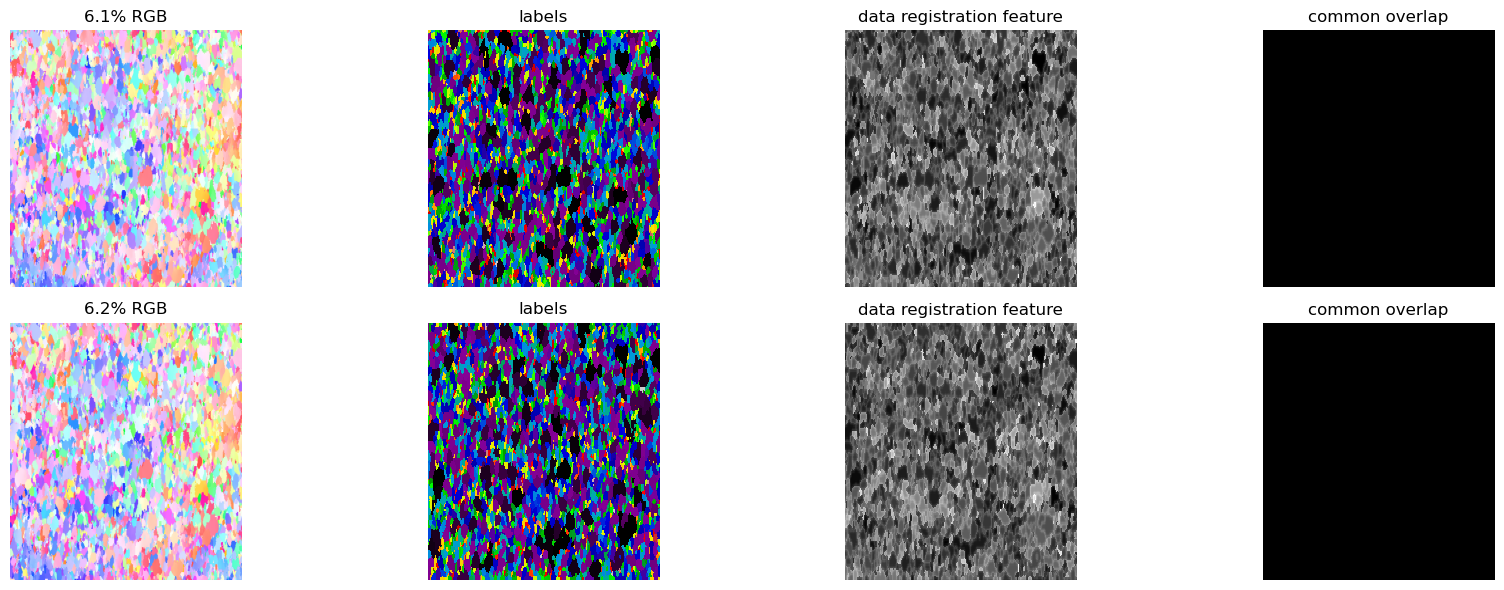

In [ ]:
z = common_mask_crop.shape[0] // 2

fig, axes = plt.subplots(len(aligned), 4, figsize=(18, 3 * len(aligned)))

if len(aligned) == 1:
    axes = axes[None, :]

for row, a in zip(axes, aligned):
    row[0].imshow(a["rgb_crop"][z], aspect=2.8)
    row[0].set_title(f"{a['strain_percent']}% RGB")
    row[0].axis("off")

    row[1].imshow(a["labels_crop"][z], cmap="nipy_spectral", interpolation="nearest", aspect=2.8)
    row[1].set_title("labels")
    row[1].axis("off")

    row[2].imshow(a["registration_feature_crop"][z], cmap="gray", interpolation="nearest", aspect=2.8)
    row[2].set_title("data registration feature")
    row[2].axis("off")

    row[3].imshow(common_mask_crop[z], cmap="gray", interpolation="nearest", aspect=2.8)
    row[3].set_title("common overlap")
    row[3].axis("off")

plt.tight_layout()
plt.show()

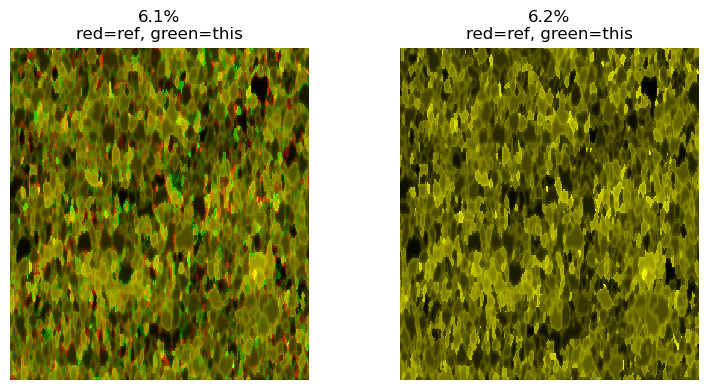

In [ ]:
# Overlay the data-registration feature against the reference feature.
ref_feat = aligned[ref_index]["registration_feature_crop"]

fig, axes = plt.subplots(1, len(aligned), figsize=(4 * len(aligned), 4))

if len(aligned) == 1:
    axes = [axes]

z = common_mask_crop.shape[0] // 2

for ax, a in zip(axes, aligned):
    feat = a["registration_feature_crop"]

    rf = robust_zscore(ref_feat[z], valid=common_mask_crop[z])
    mf = robust_zscore(feat[z], valid=common_mask_crop[z])

    overlay = np.zeros((*rf.shape, 3), dtype=float)
    overlay[..., 0] = (rf - rf.min()) / (rf.max() - rf.min() + 1e-8)
    overlay[..., 1] = (mf - mf.min()) / (mf.max() - mf.min() + 1e-8)

    ax.imshow(overlay, interpolation="nearest", aspect=2.8)
    ax.set_title(f"{a['strain_percent']}%\nred=ref, green=this")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 8. Relabel cropped labels inside the common region

In [ ]:
for a in aligned:
    lab = a["labels_crop"].copy()
    lab[~common_mask_crop] = 0
    lab, _, _ = relabel_sequential(lab)
    a["labels_common"] = np.asarray(lab, dtype=np.int32)

    coverage = np.count_nonzero((a["labels_common"] > 0) & common_mask_crop) / max(np.count_nonzero(common_mask_crop), 1)
    print(a["name"], "labels:", int(a["labels_common"].max()), "coverage:", f"{coverage:.4%}")

111_cells_2_6-1pct_mosalayers_2x_redo labels: 2675 coverage: 100.0000%
111_cells_2_6-2pct_mosalayers_2x labels: 2518 coverage: 100.0000%


## 9. Cell feature vectors for tracking

For every cell, compute:

- volume;
- centroid;
- bounding box;
- median orientation vector;
- internal orientation spread.

These are the features used for tracking and for birth/death/split/merge candidate classification.


In [ ]:
def compute_cell_features(labels, orientation, mask):
    labels = np.asarray(labels, dtype=np.int32)
    orientation = np.asarray(orientation, dtype=float)
    mask = np.asarray(mask, dtype=bool)

    rows = []
    label_ids = np.unique(labels[(labels > 0) & mask])

    for lab in label_ids:
        region = (labels == lab) & mask
        coords = np.argwhere(region)

        if coords.size == 0:
            continue

        vals = orientation[region]
        vals = vals[np.all(np.isfinite(vals), axis=1)]

        if vals.size == 0:
            continue

        centroid = coords.mean(axis=0)
        med = np.nanmedian(vals, axis=0)

        spread = np.linalg.norm(vals - med, axis=1)

        zmin, ymin, xmin = coords.min(axis=0)
        zmax, ymax, xmax = coords.max(axis=0)

        row = {
            "label": int(lab),
            "volume": int(coords.shape[0]),
            "cz": float(centroid[0]),
            "cy": float(centroid[1]),
            "cx": float(centroid[2]),
            "zmin": int(zmin),
            "ymin": int(ymin),
            "xmin": int(xmin),
            "zmax": int(zmax),
            "ymax": int(ymax),
            "xmax": int(xmax),
            "internal_spread_median": float(np.nanmedian(spread)),
            "internal_spread_mean": float(np.nanmean(spread)),
            "internal_spread_q95": float(np.nanpercentile(spread, 95)),
        }

        for c in range(orientation.shape[-1]):
            row[f"median_c{c}"] = float(med[c])

        rows.append(row)

    return pd.DataFrame(rows)


for a in aligned:
    a["cell_features"] = compute_cell_features(
        labels=a["labels_common"],
        orientation=a["seg_input_crop"],
        mask=common_mask_crop,
    )
    print(a["name"], a["cell_features"].shape)

display(aligned[0]["cell_features"].head())

111_cells_2_6-1pct_mosalayers_2x_redo (2675, 16)
111_cells_2_6-2pct_mosalayers_2x (2518, 16)


,label,volume,cz,cy,cx,zmin,ymin,xmin,zmax,ymax,xmax,internal_spread_median,internal_spread_mean,internal_spread_q95,median_c0,median_c1
0,1,2338,2.579555,112.908469,290.388794,0,103,273,5,121,306,0.004211,0.044613,0.459790,0.138137,0.501059
1,2,1905,2.331234,63.078740,464.897638,0,54,451,5,74,480,0.016461,0.051924,0.272749,0.403098,0.507229
2,3,1729,2.095431,133.790630,312.792944,0,122,295,5,144,328,0.018707,0.071890,0.412962,0.388969,0.590150
3,4,2326,2.653482,23.731298,414.235168,0,13,398,5,34,429,0.017651,0.062558,0.407917,0.458711,0.516843
4,5,1871,2.371459,127.028862,408.895243,0,119,395,5,136,426,0.010710,0.060754,0.362200,0.131184,0.063004


## 10. Candidate tracking pairs: overlap + centroid + orientation + volume

Candidate links are generated from:

1. actual spatial overlap after registration;
2. centroid proximity, even if overlap is zero.

Each candidate pair gets a score:

```text
tracking_score =
    2.0 * dice_overlap
  + 1.0 * frac_of_parent
  + 1.0 * frac_of_child
  + 1.0 * centroid_similarity
  + 1.0 * orientation_similarity
  + 0.5 * volume_similarity
```

This is intentionally simple and inspectable. Tune the thresholds, not the biological/physical interpretation.


In [ ]:
def overlap_table(labels_a, labels_b, mask, min_overlap_voxels=1):
    a = labels_a[mask].astype(np.int64)
    b = labels_b[mask].astype(np.int64)

    keep = (a > 0) & (b > 0)
    a = a[keep]
    b = b[keep]

    if len(a) == 0:
        return pd.DataFrame(columns=["label_a", "label_b", "overlap_voxels"])

    pairs = np.stack([a, b], axis=1)
    unique_pairs, counts = np.unique(pairs, axis=0, return_counts=True)

    out = pd.DataFrame({
        "label_a": unique_pairs[:, 0].astype(int),
        "label_b": unique_pairs[:, 1].astype(int),
        "overlap_voxels": counts.astype(int),
    })

    out = out[out["overlap_voxels"] >= min_overlap_voxels].copy()
    return out.reset_index(drop=True)


def centroid_candidate_pairs(features_a, features_b, max_distance):
    coords_a = features_a[["cz", "cy", "cx"]].to_numpy()
    coords_b = features_b[["cz", "cy", "cx"]].to_numpy()

    tree = cKDTree(coords_b)
    hits = tree.query_ball_point(coords_a, r=max_distance)

    rows = []
    labels_a = features_a["label"].to_numpy()
    labels_b = features_b["label"].to_numpy()

    for i, js in enumerate(hits):
        for j in js:
            rows.append((int(labels_a[i]), int(labels_b[j])))

    return pd.DataFrame(rows, columns=["label_a", "label_b"]).drop_duplicates()


def tracking_candidates_shape_orientation(
    labels_a,
    labels_b,
    features_a,
    features_b,
    mask,
    min_overlap_voxels=5,
    max_centroid_distance=25.0,
    centroid_scale=10.0,
    orientation_scale=0.25,
):
    overlaps = overlap_table(
        labels_a,
        labels_b,
        mask,
        min_overlap_voxels=min_overlap_voxels,
    )

    centroid_pairs = centroid_candidate_pairs(
        features_a,
        features_b,
        max_distance=max_centroid_distance,
    )

    if overlaps.empty:
        pair_df = centroid_pairs.copy()
        pair_df["overlap_voxels"] = 0
    else:
        pair_df = pd.concat(
            [
                overlaps[["label_a", "label_b"]],
                centroid_pairs[["label_a", "label_b"]],
            ],
            ignore_index=True,
        ).drop_duplicates()

        pair_df = pair_df.merge(overlaps, on=["label_a", "label_b"], how="left")
        pair_df["overlap_voxels"] = pair_df["overlap_voxels"].fillna(0).astype(int)

    if pair_df.empty:
        return pair_df

    fa = features_a.add_suffix("_a").rename(columns={"label_a": "label_a"})
    fb = features_b.add_suffix("_b").rename(columns={"label_b": "label_b"})

    df = pair_df.merge(fa, on="label_a", how="left")
    df = df.merge(fb, on="label_b", how="left")

    df = df.dropna(subset=["volume_a", "volume_b"]).copy()

    df["frac_of_a"] = df["overlap_voxels"] / df["volume_a"]
    df["frac_of_b"] = df["overlap_voxels"] / df["volume_b"]
    df["dice_overlap"] = (
        2.0 * df["overlap_voxels"] / (df["volume_a"] + df["volume_b"])
    )

    dz = df["cz_b"] - df["cz_a"]
    dy = df["cy_b"] - df["cy_a"]
    dx = df["cx_b"] - df["cx_a"]
    df["centroid_distance"] = np.sqrt(dz**2 + dy**2 + dx**2)

    orientation_cols_a = sorted(
        [c for c in df.columns if c.startswith("median_c") and c.endswith("_a")]
    )
    orientation_cols_b = sorted(
        [c for c in df.columns if c.startswith("median_c") and c.endswith("_b")]
    )

    da = df[orientation_cols_a].to_numpy()
    db = df[orientation_cols_b].to_numpy()

    df["orientation_difference"] = np.linalg.norm(db - da, axis=1)

    df["volume_similarity"] = (
        np.minimum(df["volume_a"], df["volume_b"])
        / np.maximum(df["volume_a"], df["volume_b"])
    )

    df["centroid_similarity"] = np.exp(-df["centroid_distance"] / centroid_scale)
    df["orientation_similarity"] = np.exp(
        -df["orientation_difference"] / orientation_scale
    )

    df["tracking_score"] = (
        2.0 * df["dice_overlap"]
        + 1.0 * df["frac_of_a"]
        + 1.0 * df["frac_of_b"]
        + 1.0 * df["centroid_similarity"]
        + 1.0 * df["orientation_similarity"]
        + 0.5 * df["volume_similarity"]
    )

    df = df.sort_values("tracking_score", ascending=False).reset_index(drop=True)
    return df


def greedy_one_to_one_assignment(candidates, min_score=1.0):
    assigned_a = set()
    assigned_b = set()
    rows = []

    for _, row in candidates.sort_values("tracking_score", ascending=False).iterrows():
        la = int(row["label_a"])
        lb = int(row["label_b"])

        if row["tracking_score"] < min_score:
            continue
        if la in assigned_a or lb in assigned_b:
            continue

        assigned_a.add(la)
        assigned_b.add(lb)
        rows.append(row)

    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows)


def classify_birth_death_split_merge(
    candidates,
    features_a,
    features_b,
    assignments,
    min_score=1.0,
    min_frac_parent=0.05,
):
    """
    Candidate event classification.

    - one_to_one: greedy assignment exists.
    - split_candidate: one parent has several significant children.
    - merge_candidate: one child has several significant parents.
    - death_candidate: parent has no significant candidate.
    - birth_candidate: child has no significant candidate.
    """
    if candidates.empty:
        return pd.DataFrame()

    sig = candidates[
        (candidates["tracking_score"] >= min_score)
        & (
            (candidates["frac_of_a"] >= min_frac_parent)
            | (candidates["frac_of_b"] >= min_frac_parent)
            | (candidates["centroid_distance"] <= max_centroid_distance)
        )
    ].copy()

    assigned_pairs = set()
    if len(assignments):
        assigned_pairs = set(
            zip(assignments["label_a"].astype(int), assignments["label_b"].astype(int))
        )

    children_per_parent = sig.groupby("label_a")["label_b"].nunique()
    parents_per_child = sig.groupby("label_b")["label_a"].nunique()

    significant_parents = set(sig["label_a"].astype(int))
    significant_children = set(sig["label_b"].astype(int))

    assigned_parents = set(assignments["label_a"].astype(int)) if len(assignments) else set()
    assigned_children = set(assignments["label_b"].astype(int)) if len(assignments) else set()

    rows = []

    # One-to-one assigned tracks
    for la, lb in assigned_pairs:
        rows.append({
            "event": "one_to_one",
            "label_a": int(la),
            "label_b": int(lb),
            "n_children": int(children_per_parent.get(la, 0)),
            "n_parents": int(parents_per_child.get(lb, 0)),
        })

    # Split candidates
    for la, n_child in children_per_parent.items():
        la = int(la)
        n_child = int(n_child)
        if n_child > 1:
            rows.append({
                "event": "split_candidate",
                "label_a": la,
                "label_b": 0,
                "n_children": n_child,
                "n_parents": np.nan,
            })

    # Merge candidates
    for lb, n_parent in parents_per_child.items():
        lb = int(lb)
        n_parent = int(n_parent)
        if n_parent > 1:
            rows.append({
                "event": "merge_candidate",
                "label_a": 0,
                "label_b": lb,
                "n_children": np.nan,
                "n_parents": n_parent,
            })

    # Death and birth candidates: no significant candidate at all
    all_parents = set(features_a["label"].astype(int))
    all_children = set(features_b["label"].astype(int))

    for la in sorted(all_parents - significant_parents):
        rows.append({
            "event": "death_candidate",
            "label_a": int(la),
            "label_b": 0,
            "n_children": 0,
            "n_parents": np.nan,
        })

    for lb in sorted(all_children - significant_children):
        rows.append({
            "event": "birth_candidate",
            "label_a": 0,
            "label_b": int(lb),
            "n_children": np.nan,
            "n_parents": 0,
        })

    return pd.DataFrame(rows)

## 11. Run feature-vector tracking across strain

In [ ]:
tracking_dir = output_root / "tracking_data_registered_feature_vectors"
tracking_dir.mkdir(exist_ok=True)

tracking_pairs = []
tracking_event_summaries = []
assignment_summaries = []

for i in range(len(aligned) - 1):
    a = aligned[i]
    b = aligned[i + 1]

    candidates = tracking_candidates_shape_orientation(
        labels_a=a["labels_common"],
        labels_b=b["labels_common"],
        features_a=a["cell_features"],
        features_b=b["cell_features"],
        mask=common_mask_crop,
        min_overlap_voxels=min_overlap_voxels,
        max_centroid_distance=max_centroid_distance,
        centroid_scale=centroid_scale,
        orientation_scale=orientation_scale,
    )

    assignments = greedy_one_to_one_assignment(
        candidates,
        min_score=min_score_for_assignment,
    )

    events = classify_birth_death_split_merge(
        candidates,
        features_a=a["cell_features"],
        features_b=b["cell_features"],
        assignments=assignments,
        min_score=min_score_for_events,
        min_frac_parent=min_frac_parent_for_events,
    )

    pair_name = f"{i:02d}_{a['strain_percent']}_to_{b['strain_percent']}"

    candidates.to_csv(tracking_dir / f"{pair_name}_tracking_candidates.csv", index=False)
    assignments.to_csv(tracking_dir / f"{pair_name}_one_to_one_assignments.csv", index=False)
    events.to_csv(tracking_dir / f"{pair_name}_events.csv", index=False)
    a["cell_features"].to_csv(tracking_dir / f"{pair_name}_features_a.csv", index=False)
    b["cell_features"].to_csv(tracking_dir / f"{pair_name}_features_b.csv", index=False)

    event_counts = (
        events["event"].value_counts().rename_axis("event").rename("count").reset_index()
        if len(events)
        else pd.DataFrame(columns=["event", "count"])
    )
    event_counts["from"] = a["strain_percent"]
    event_counts["to"] = b["strain_percent"]

    tracking_event_summaries.append(event_counts)

    assignment_summaries.append({
        "from": a["strain_percent"],
        "to": b["strain_percent"],
        "n_candidates": int(len(candidates)),
        "n_assignments": int(len(assignments)),
        "mean_assignment_score": float(assignments["tracking_score"].mean()) if len(assignments) else np.nan,
        "median_assignment_score": float(assignments["tracking_score"].median()) if len(assignments) else np.nan,
        "mean_orientation_difference": float(assignments["orientation_difference"].mean()) if len(assignments) else np.nan,
        "median_orientation_difference": float(assignments["orientation_difference"].median()) if len(assignments) else np.nan,
        "mean_centroid_distance": float(assignments["centroid_distance"].mean()) if len(assignments) else np.nan,
        "median_centroid_distance": float(assignments["centroid_distance"].median()) if len(assignments) else np.nan,
        "mean_dice_overlap": float(assignments["dice_overlap"].mean()) if len(assignments) else np.nan,
        "median_dice_overlap": float(assignments["dice_overlap"].median()) if len(assignments) else np.nan,
    })

    tracking_pairs.append({
        "pair_name": pair_name,
        "from_index": i,
        "to_index": i + 1,
        "candidates": candidates,
        "assignments": assignments,
        "events": events,
    })

    print("\n", pair_name)
    print("candidates:", len(candidates))
    print("one-to-one assignments:", len(assignments))
    print("events:")
    print(event_counts)
    display(candidates.head(10))
    display(assignments.head(10))

tracking_summary = (
    pd.concat(tracking_event_summaries, ignore_index=True)
    if tracking_event_summaries
    else pd.DataFrame(columns=["event", "count", "from", "to"])
)

assignment_summary = pd.DataFrame(assignment_summaries)

tracking_summary.to_csv(tracking_dir / "tracking_event_summary.csv", index=False)
assignment_summary.to_csv(tracking_dir / "assignment_summary.csv", index=False)

display(tracking_summary)
display(assignment_summary)


 00_6.1_to_6.2
candidates: 122426
one-to-one assignments: 2255
events:
             event  count  from   to
0  split_candidate   2593   6.1  6.2
1  merge_candidate   2442   6.1  6.2
2       one_to_one   2255   6.1  6.2
3  death_candidate     21   6.1  6.2
4  birth_candidate     21   6.1  6.2


,label_a,label_b,overlap_voxels,volume_a,cz_a,cy_a,cx_a,zmin_a,ymin_a,xmin_a,...,median_c1_b,frac_of_a,frac_of_b,dice_overlap,centroid_distance,orientation_difference,volume_similarity,centroid_similarity,orientation_similarity,tracking_score
0,34,6,1593,1679,2.675402,118.762954,21.606909,0,110,10,...,0.543681,0.948779,0.867175,0.906143,0.240332,0.017161,0.913990,0.976253,0.933661,5.995150
1,247,59,620,658,2.802432,44.820669,203.477204,0,39,196,...,0.876309,0.942249,0.864714,0.901818,0.254644,0.017914,0.917713,0.974857,0.930850,5.975163
2,1,4,2092,2338,2.579555,112.908469,290.388794,0,103,273,...,0.514231,0.894782,0.914735,0.904649,0.893944,0.013201,0.978186,0.914485,0.948567,5.970960
3,69,72,793,875,2.605714,4.699429,134.776000,0,0,125,...,0.867046,0.906286,0.894025,0.900114,0.449698,0.025480,0.986471,0.956026,0.903102,5.952901
4,289,236,470,513,2.510721,113.280702,238.608187,0,109,232,...,0.878579,0.916179,0.871985,0.893536,0.483653,0.021352,0.951763,0.952786,0.918137,5.922041
5,138,37,976,1105,2.624434,41.372851,15.295023,0,34,5,...,0.451298,0.883258,0.893773,0.888484,0.162013,0.033407,0.988235,0.983929,0.874915,5.906962
6,7,36,1397,1687,2.435092,50.973918,163.714286,0,43,151,...,0.680340,0.828097,0.958819,0.888677,0.381979,0.019921,0.863663,0.962522,0.923409,5.882033
7,17,35,1338,1541,2.481506,115.539260,123.125892,0,108,110,...,0.628297,0.868267,0.925311,0.895882,0.493056,0.033974,0.938352,0.951890,0.872932,5.879341
8,35,12,1414,1578,2.707224,6.861850,53.224335,0,0,37,...,0.635153,0.896071,0.877171,0.886520,1.125819,0.015731,0.978908,0.893524,0.939014,5.868276
9,22,45,1268,1409,2.462740,81.968772,9.474095,0,74,0,...,0.604481,0.899929,0.881780,0.890762,0.891224,0.026665,0.979833,0.914734,0.898832,5.866716


,label_a,label_b,overlap_voxels,volume_a,cz_a,cy_a,cx_a,zmin_a,ymin_a,xmin_a,...,median_c1_b,frac_of_a,frac_of_b,dice_overlap,centroid_distance,orientation_difference,volume_similarity,centroid_similarity,orientation_similarity,tracking_score
0,34.0,6.0,1593.0,1679.0,2.675402,118.762954,21.606909,0.0,110.0,10.0,...,0.543681,0.948779,0.867175,0.906143,0.240332,0.017161,0.913990,0.976253,0.933661,5.995150
1,247.0,59.0,620.0,658.0,2.802432,44.820669,203.477204,0.0,39.0,196.0,...,0.876309,0.942249,0.864714,0.901818,0.254644,0.017914,0.917713,0.974857,0.930850,5.975163
2,1.0,4.0,2092.0,2338.0,2.579555,112.908469,290.388794,0.0,103.0,273.0,...,0.514231,0.894782,0.914735,0.904649,0.893944,0.013201,0.978186,0.914485,0.948567,5.970960
3,69.0,72.0,793.0,875.0,2.605714,4.699429,134.776000,0.0,0.0,125.0,...,0.867046,0.906286,0.894025,0.900114,0.449698,0.025480,0.986471,0.956026,0.903102,5.952901
4,289.0,236.0,470.0,513.0,2.510721,113.280702,238.608187,0.0,109.0,232.0,...,0.878579,0.916179,0.871985,0.893536,0.483653,0.021352,0.951763,0.952786,0.918137,5.922041
5,138.0,37.0,976.0,1105.0,2.624434,41.372851,15.295023,0.0,34.0,5.0,...,0.451298,0.883258,0.893773,0.888484,0.162013,0.033407,0.988235,0.983929,0.874915,5.906962
6,7.0,36.0,1397.0,1687.0,2.435092,50.973918,163.714286,0.0,43.0,151.0,...,0.680340,0.828097,0.958819,0.888677,0.381979,0.019921,0.863663,0.962522,0.923409,5.882033
7,17.0,35.0,1338.0,1541.0,2.481506,115.539260,123.125892,0.0,108.0,110.0,...,0.628297,0.868267,0.925311,0.895882,0.493056,0.033974,0.938352,0.951890,0.872932,5.879341
8,35.0,12.0,1414.0,1578.0,2.707224,6.861850,53.224335,0.0,0.0,37.0,...,0.635153,0.896071,0.877171,0.886520,1.125819,0.015731,0.978908,0.893524,0.939014,5.868276
9,22.0,45.0,1268.0,1409.0,2.462740,81.968772,9.474095,0.0,74.0,0.0,...,0.604481,0.899929,0.881780,0.890762,0.891224,0.026665,0.979833,0.914734,0.898832,5.866716


,event,count,from,to
0,split_candidate,2593,6.1,6.2
1,merge_candidate,2442,6.1,6.2
2,one_to_one,2255,6.1,6.2
3,death_candidate,21,6.1,6.2
4,birth_candidate,21,6.1,6.2


,from,to,n_candidates,n_assignments,mean_assignment_score,median_assignment_score,mean_orientation_difference,median_orientation_difference,mean_centroid_distance,median_centroid_distance,mean_dice_overlap,median_dice_overlap
0,6.1,6.2,122426,2255,3.752033,4.24427,0.087258,0.032412,3.650705,1.934722,0.458714,0.535714


## 12. Event fractions and assignment diagnostics

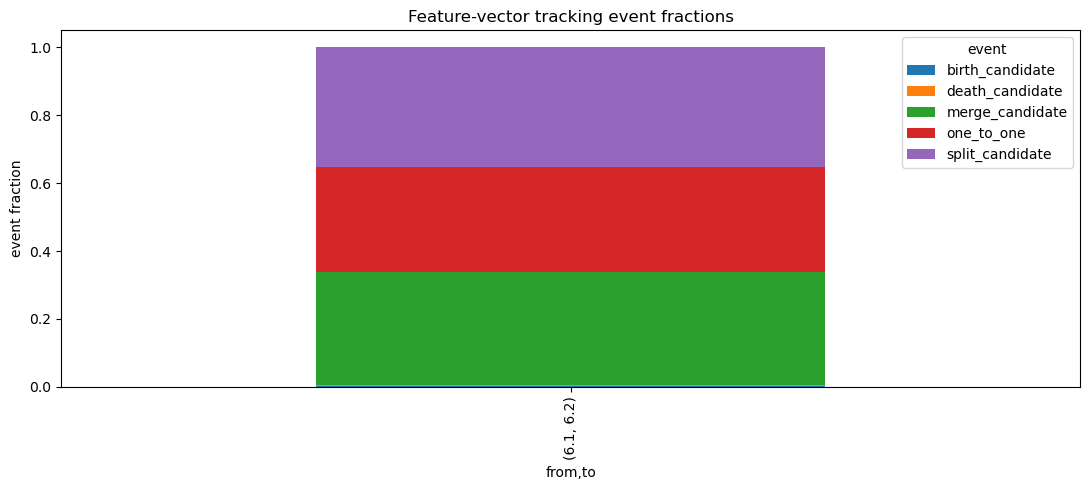

,event,birth_candidate,death_candidate,merge_candidate,one_to_one,split_candidate
from,to,,,,,
6.1,6.2,21.0,21.0,2442.0,2255.0,2593.0


,event,birth_candidate,death_candidate,merge_candidate,one_to_one,split_candidate
from,to,,,,,
6.1,6.2,0.002864,0.002864,0.333061,0.307556,0.353655


In [ ]:
if len(tracking_summary):
    pivot = tracking_summary.pivot_table(
        index=["from", "to"],
        columns="event",
        values="count",
        fill_value=0,
    )
    pivot_fraction = pivot.div(pivot.sum(axis=1), axis=0)

    ax = pivot_fraction.plot(kind="bar", stacked=True, figsize=(11, 5))
    ax.set_ylabel("event fraction")
    ax.set_title("Feature-vector tracking event fractions")
    plt.tight_layout()
    plt.show()

    display(pivot)
    display(pivot_fraction)
else:
    print("No tracking events available.")

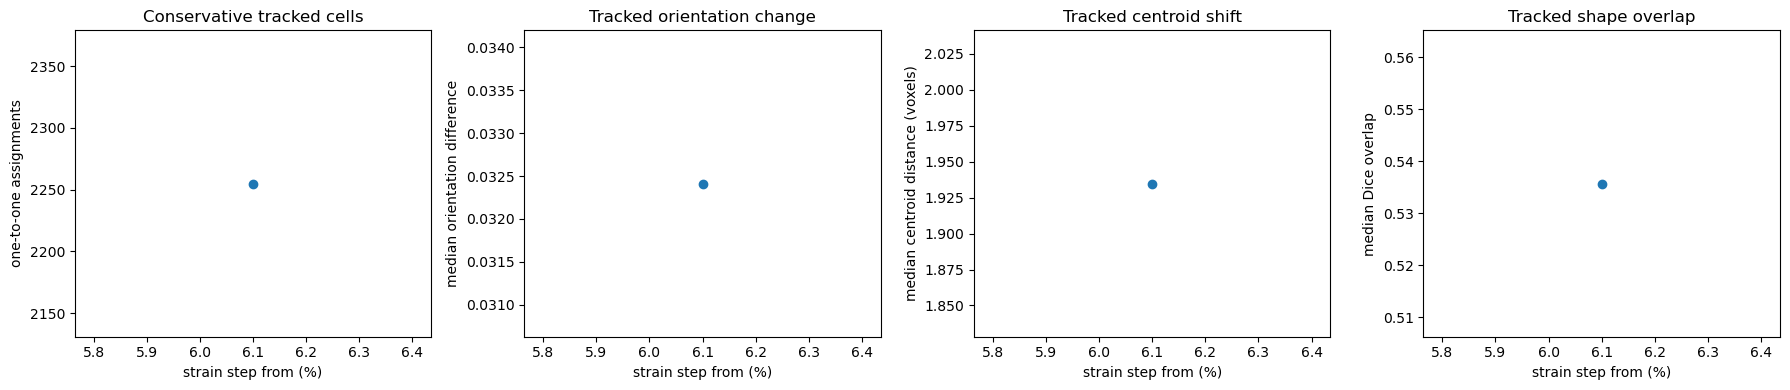

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(assignment_summary["from"], assignment_summary["n_assignments"], marker="o")
axes[0].set_xlabel("strain step from (%)")
axes[0].set_ylabel("one-to-one assignments")
axes[0].set_title("Conservative tracked cells")

axes[1].plot(assignment_summary["from"], assignment_summary["median_orientation_difference"], marker="o")
axes[1].set_xlabel("strain step from (%)")
axes[1].set_ylabel("median orientation difference")
axes[1].set_title("Tracked orientation change")

axes[2].plot(assignment_summary["from"], assignment_summary["median_centroid_distance"], marker="o")
axes[2].set_xlabel("strain step from (%)")
axes[2].set_ylabel("median centroid distance (voxels)")
axes[2].set_title("Tracked centroid shift")

axes[3].plot(assignment_summary["from"], assignment_summary["median_dice_overlap"], marker="o")
axes[3].set_xlabel("strain step from (%)")
axes[3].set_ylabel("median Dice overlap")
axes[3].set_title("Tracked shape overlap")

plt.tight_layout()
plt.show()

## 13. Inspect candidate events

pair: 00_6.1_to_6.2
event counts:


event
split_candidate    2593
merge_candidate    2442
one_to_one         2255
death_candidate      21
birth_candidate      21
Name: count, dtype: int64

number of split candidates: 2593
parent: 2526
children: [1329 1509 2011 2061 2015  137  868 1391 2244  770 2021 1413 1080 1697
 1838  917 2262 1919  883 1967 1839 1591 1979 2465 1231 1436  896 1959
 2419  828]


,label_a,label_b,overlap_voxels,volume_a,cz_a,cy_a,cx_a,zmin_a,ymin_a,xmin_a,...,median_c1_b,frac_of_a,frac_of_b,dice_overlap,centroid_distance,orientation_difference,volume_similarity,centroid_similarity,orientation_similarity,tracking_score
1854,2526,1329,19,81,3.82716,176.259259,50.432099,0,174,48,...,0.723408,0.234568,0.231707,0.233129,4.260335,0.058926,0.987805,0.653094,0.790016,2.869546
2365,2526,1509,37,81,3.82716,176.259259,50.432099,0,174,48,...,0.736940,0.456790,0.108504,0.175355,6.417615,0.049263,0.237537,0.526364,0.821147,2.382285
7924,2526,2011,0,81,3.82716,176.259259,50.432099,0,174,48,...,0.749712,0.000000,0.000000,0.000000,14.591568,0.068586,0.698276,0.232432,0.760071,1.341641
8411,2526,2061,0,81,3.82716,176.259259,50.432099,0,174,48,...,0.773227,0.000000,0.000000,0.000000,5.905873,0.114293,0.259259,0.554002,0.633072,1.316703
10029,2526,2015,0,81,3.82716,176.259259,50.432099,0,174,48,...,0.637819,0.000000,0.000000,0.000000,23.396998,0.084480,0.880435,0.096357,0.713252,1.249825
10761,2526,137,16,81,3.82716,176.259259,50.432099,0,174,48,...,0.673642,0.197531,0.012012,0.022647,8.823798,0.161382,0.060811,0.413797,0.524387,1.223426
11073,2526,868,0,81,3.82716,176.259259,50.432099,0,174,48,...,0.750392,0.000000,0.000000,0.000000,12.927800,0.062324,0.318898,0.274507,0.779349,1.213305
11519,2526,1391,0,81,3.82716,176.259259,50.432099,0,174,48,...,0.626644,0.000000,0.000000,0.000000,13.871261,0.076853,0.428571,0.249792,0.735348,1.199426
12542,2526,2244,0,81,3.82716,176.259259,50.432099,0,174,48,...,0.762042,0.000000,0.000000,0.000000,15.409472,0.066819,0.382716,0.214178,0.765461,1.170997
12573,2526,770,0,81,3.82716,176.259259,50.432099,0,174,48,...,0.671836,0.000000,0.000000,0.000000,9.988054,0.083435,0.171247,0.368319,0.716240,1.170183


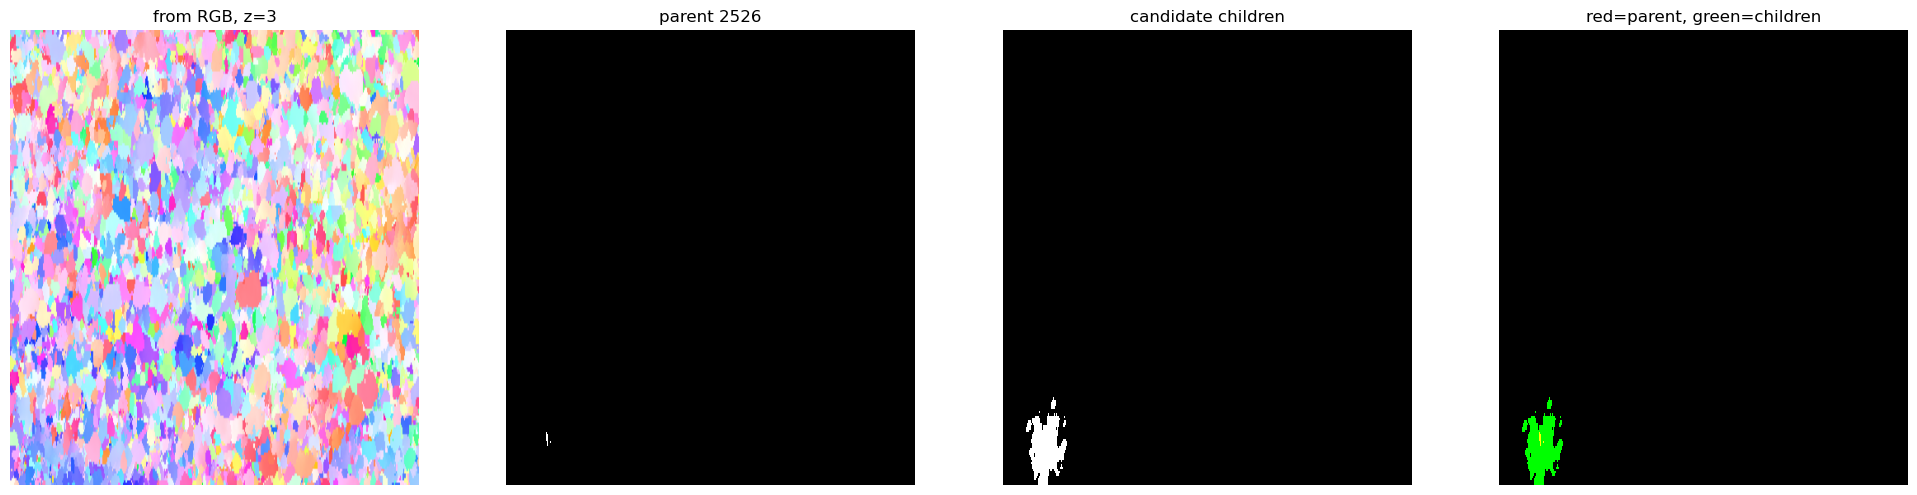

In [ ]:
# Choose transition index to inspect.
transition_index = 0

pair = tracking_pairs[transition_index]
a = aligned[pair["from_index"]]
b = aligned[pair["to_index"]]

events = pair["events"]
candidates = pair["candidates"]
assignments = pair["assignments"]

print("pair:", pair["pair_name"])
print("event counts:")
display(events["event"].value_counts() if len(events) else events)

split_labels = (
    events.loc[events["event"] == "split_candidate", "label_a"].astype(int).to_numpy()
    if len(events)
    else np.array([], dtype=int)
)

print("number of split candidates:", len(split_labels))

if len(split_labels):
    split_scores = []

    for lab in split_labels:
        rows = candidates[
            (candidates["label_a"] == lab)
            & (candidates["tracking_score"] >= min_score_for_events)
        ]
        total_score = rows["tracking_score"].sum()
        total_overlap = rows["overlap_voxels"].sum()
        split_scores.append((lab, total_score, total_overlap))

    split_scores = sorted(split_scores, key=lambda x: x[1], reverse=True)

    lab = split_scores[0][0]
    rows = candidates[
        (candidates["label_a"] == lab)
        & (candidates["tracking_score"] >= min_score_for_events)
    ].sort_values("tracking_score", ascending=False)

    children = rows["label_b"].astype(int).to_numpy()

    print("parent:", lab)
    print("children:", children)
    display(rows)

    parent_mask = a["labels_common"] == lab
    child_mask = np.isin(b["labels_common"], children)

    coords = np.argwhere(parent_mask | child_mask)
    z = int(np.median(coords[:, 0])) if len(coords) else common_mask_crop.shape[0] // 2

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(a["rgb_crop"][z], aspect=2.8)
    axes[0].set_title(f"from RGB, z={z}")
    axes[0].axis("off")

    axes[1].imshow(parent_mask[z], cmap="gray", interpolation="nearest", aspect=2.8)
    axes[1].set_title(f"parent {lab}")
    axes[1].axis("off")

    axes[2].imshow(child_mask[z], cmap="gray", interpolation="nearest", aspect=2.8)
    axes[2].set_title("candidate children")
    axes[2].axis("off")

    overlay = np.zeros((*parent_mask[z].shape, 3), dtype=float)
    overlay[..., 0] = parent_mask[z]
    overlay[..., 1] = child_mask[z]
    axes[3].imshow(overlay, interpolation="nearest", aspect=2.8)
    axes[3].set_title("red=parent, green=children")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No split candidates in this transition.")

best assignment
label_a: 34
label_b: 6
score: 5.995149664521525
orientation_difference: 0.017160526138779494
centroid_distance: 0.24033172353250662
dice_overlap: 0.9061433447098977


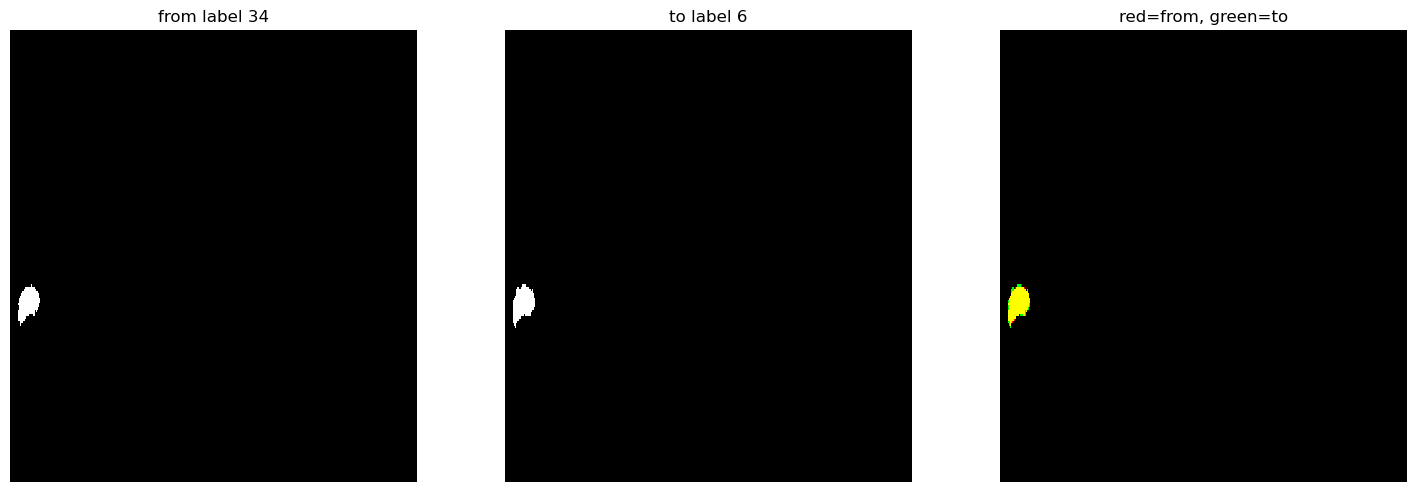

In [ ]:
# Inspect strongest one-to-one assignment for the selected transition.
if len(assignments):
    row = assignments.sort_values("tracking_score", ascending=False).iloc[0]

    lab_a = int(row["label_a"])
    lab_b = int(row["label_b"])

    print("best assignment")
    print("label_a:", lab_a)
    print("label_b:", lab_b)
    print("score:", row["tracking_score"])
    print("orientation_difference:", row["orientation_difference"])
    print("centroid_distance:", row["centroid_distance"])
    print("dice_overlap:", row["dice_overlap"])

    mask_a = a["labels_common"] == lab_a
    mask_b = b["labels_common"] == lab_b

    coords = np.argwhere(mask_a | mask_b)
    z = int(np.median(coords[:, 0])) if len(coords) else common_mask_crop.shape[0] // 2

    overlay = np.zeros((*mask_a[z].shape, 3), dtype=float)
    overlay[..., 0] = mask_a[z]
    overlay[..., 1] = mask_b[z]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(mask_a[z], cmap="gray", interpolation="nearest", aspect=2.8)
    axes[0].set_title(f"from label {lab_a}")
    axes[0].axis("off")

    axes[1].imshow(mask_b[z], cmap="gray", interpolation="nearest", aspect=2.8)
    axes[1].set_title(f"to label {lab_b}")
    axes[1].axis("off")

    axes[2].imshow(overlay, interpolation="nearest", aspect=2.8)
    axes[2].set_title("red=from, green=to")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No one-to-one assignments available.")

## 14. Common-region cell statistics and χ fits

In [ ]:
def neighbour_offsets():
    offsets = []
    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:
            if dy == 0 and dx == 0:
                continue
            offsets.append((0, dy, dx))
    offsets.append((-1, 0, 0))
    offsets.append((1, 0, 0))

    unique_offsets = []
    seen = set()
    for dz, dy, dx in offsets:
        a = (dz, dy, dx)
        b = (-dz, -dy, -dx)
        if b in seen:
            continue
        seen.add(a)
        unique_offsets.append(a)
    return unique_offsets


def find_neighbour_pairs(labels, mask):
    Z, Y, X = labels.shape
    pairs = set()

    for dz, dy, dx in neighbour_offsets():
        z0a, z1a = max(0, dz), Z + min(0, dz)
        y0a, y1a = max(0, dy), Y + min(0, dy)
        x0a, x1a = max(0, dx), X + min(0, dx)

        z0b, z1b = max(0, -dz), Z + min(0, -dz)
        y0b, y1b = max(0, -dy), Y + min(0, -dy)
        x0b, x1b = max(0, -dx), X + min(0, -dx)

        a = labels[z0a:z1a, y0a:y1a, x0a:x1a]
        b = labels[z0b:z1b, y0b:y1b, x0b:x1b]
        ma = mask[z0a:z1a, y0a:y1a, x0a:x1a]
        mb = mask[z0b:z1b, y0b:y1b, x0b:x1b]

        contact = (a > 0) & (b > 0) & (a != b) & ma & mb
        if not np.any(contact):
            continue

        aa = a[contact].astype(np.int64)
        bb = b[contact].astype(np.int64)
        lo = np.minimum(aa, bb)
        hi = np.maximum(aa, bb)
        for p in zip(lo, hi):
            pairs.add(p)

    if not pairs:
        return np.zeros((0, 2), dtype=np.int64)
    return np.array(sorted(pairs), dtype=np.int64)


def compute_neighbour_table(labels, features_df):
    med_cols = sorted([c for c in features_df.columns if c.startswith("median_c")])
    med = features_df.set_index("label")[med_cols]

    pairs = find_neighbour_pairs(labels, common_mask_crop)

    rows = []
    for la, lb in pairs:
        if la not in med.index or lb not in med.index:
            continue

        va = med.loc[la].to_numpy(dtype=float)
        vb = med.loc[lb].to_numpy(dtype=float)
        dvec = vb - va

        row = {
            "label_a": int(la),
            "label_b": int(lb),
            "misorientation": float(np.linalg.norm(dvec)),
        }
        for c, dv in enumerate(dvec):
            row[f"delta_c{c}"] = float(dv)
        rows.append(row)

    return pd.DataFrame(rows)


def fit_chi(mis):
    mis = np.asarray(mis, dtype=float)
    mis = mis[np.isfinite(mis)]
    mis = mis[mis > 0]
    if len(mis) < 10:
        return np.nan, np.nan
    k_hat, _, sigma_hat = stats.chi.fit(mis, floc=0)
    return float(k_hat), float(sigma_hat)


common_stats = []

for a in aligned:
    neigh_df = compute_neighbour_table(a["labels_common"], a["cell_features"])
    a["common_neighbour_table"] = neigh_df

    k_hat, sigma_hat = fit_chi(neigh_df["misorientation"].to_numpy() if len(neigh_df) else np.array([]))

    common_stats.append({
        "dataset": a["name"],
        "strain_percent": a["strain_percent"],
        "n_cells": int(a["labels_common"].max()),
        "n_neighbour_pairs": int(len(neigh_df)),
        "median_cell_volume_voxels": float(a["cell_features"]["volume"].median()),
        "mean_cell_volume_voxels": float(a["cell_features"]["volume"].mean()),
        "chi_k": k_hat,
        "chi_sigma": sigma_hat,
        "mean_neighbour_misorientation": float(neigh_df["misorientation"].mean()) if len(neigh_df) else np.nan,
        "median_neighbour_misorientation": float(neigh_df["misorientation"].median()) if len(neigh_df) else np.nan,
    })

common_stats_df = pd.DataFrame(common_stats)
common_stats_df

,dataset,strain_percent,n_cells,n_neighbour_pairs,median_cell_volume_voxels,mean_cell_volume_voxels,chi_k,chi_sigma,mean_neighbour_misorientation,median_neighbour_misorientation
0,111_cells_2_6-1pct_mosalayers_2x_redo,6.1,2675,10843,123.0,218.981682,1.675897,0.332290,0.374620,0.349211
1,111_cells_2_6-2pct_mosalayers_2x,6.2,2518,10157,132.0,232.635425,1.708063,0.331078,0.377231,0.351562


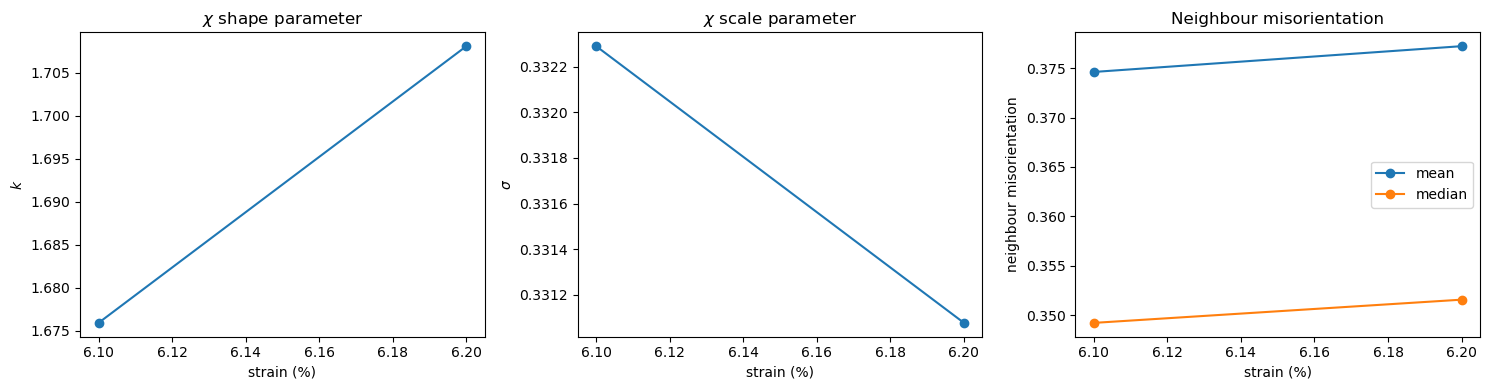

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(common_stats_df["strain_percent"], common_stats_df["chi_k"], marker="o")
axes[0].set_xlabel("strain (%)")
axes[0].set_ylabel(r"$k$")
axes[0].set_title(r"$\chi$ shape parameter")

axes[1].plot(common_stats_df["strain_percent"], common_stats_df["chi_sigma"], marker="o")
axes[1].set_xlabel("strain (%)")
axes[1].set_ylabel(r"$\sigma$")
axes[1].set_title(r"$\chi$ scale parameter")

axes[2].plot(common_stats_df["strain_percent"], common_stats_df["mean_neighbour_misorientation"], marker="o", label="mean")
axes[2].plot(common_stats_df["strain_percent"], common_stats_df["median_neighbour_misorientation"], marker="o", label="median")
axes[2].set_xlabel("strain (%)")
axes[2].set_ylabel("neighbour misorientation")
axes[2].set_title("Neighbour misorientation")
axes[2].legend()

plt.tight_layout()
plt.show()

## 15. Save outputs

In [ ]:
aligned_dir = output_root / "data_registered_feature_tracking_common_crop"
aligned_dir.mkdir(exist_ok=True)

np.save(aligned_dir / "common_mask_crop.npy", common_mask_crop)
registration_table.to_csv(aligned_dir / "data_registration_table.csv", index=False)
tracking_summary.to_csv(aligned_dir / "feature_tracking_event_summary.csv", index=False)
assignment_summary.to_csv(aligned_dir / "feature_assignment_summary.csv", index=False)
common_stats_df.to_csv(aligned_dir / "common_region_cell_statistics.csv", index=False)

for a in aligned:
    safe = str(a["strain_percent"]).replace(".", "p")
    np.save(aligned_dir / f"{safe}_labels_common.npy", a["labels_common"])
    np.save(aligned_dir / f"{safe}_registered_crop.npy", a["registered_crop"])
    np.save(aligned_dir / f"{safe}_seg_input_crop.npy", a["seg_input_crop"])
    np.save(aligned_dir / f"{safe}_mask_crop.npy", a["mask_crop"])
    np.save(aligned_dir / f"{safe}_rgb_crop.npy", a["rgb_crop"])
    np.save(aligned_dir / f"{safe}_registration_feature_crop.npy", a["registration_feature_crop"])

    a["cell_features"].to_csv(aligned_dir / f"{safe}_cell_features.csv", index=False)
    a["common_neighbour_table"].to_csv(aligned_dir / f"{safe}_neighbour_table_common.csv", index=False)

print("saved:", aligned_dir)
print("tracking saved:", tracking_dir)

saved: /home/adam/Documents/Data/4dcells/111_june/disell_batch_output/data_registered_feature_tracking_common_crop
tracking saved: /home/adam/Documents/Data/4dcells/111_june/disell_batch_output/tracking_data_registered_feature_vectors
